In [1]:
# ---- Kjør denne først i notebooken ----
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # tving CPU selv om CUDA finnes

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

torch.set_num_threads(1)  # ekstra stabilt i noen Jupyter-oppsett

# ---- Last data ----
df = pd.read_csv("../processed_player_value/nn_tabular_dataset.csv")

TARGET = "y_log"
GROUP_COL = "player_id"

# ---- Features: kun numeriske (unngår valuation_date/object) ----
num = df.select_dtypes(include=[np.number]).copy()

X_df = num.drop(columns=[c for c in ["y_raw", "y_log", "player_id"] if c in num.columns], errors="ignore")

# ---- Rydd NaN/inf ----
X_df = X_df.replace([np.inf, -np.inf], np.nan)
y_ser = df[TARGET].replace([np.inf, -np.inf], np.nan)

mask = (~X_df.isna().any(axis=1)) & (~y_ser.isna())
X_df = X_df.loc[mask]
y_ser = y_ser.loc[mask]
groups = df.loc[mask, GROUP_COL].values

X = X_df.to_numpy(dtype=np.float32)
y = y_ser.to_numpy(dtype=np.float32).reshape(-1, 1)

print("X:", X.shape, "y:", y.shape)

# ---- Leakage-sikker split (group by player_id) ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ---- Skalering ----
scaler = StandardScaler(copy=False)
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# ---- Dataset/DataLoader ----
class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TabDataset(X_train, y_train), batch_size=256, shuffle=True, num_workers=0)
test_loader  = DataLoader(TabDataset(X_test, y_test), batch_size=2048, shuffle=False, num_workers=0)

# ---- Modell ----
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 1),
        )
    def forward(self, x): return self.net(x)

device = "cpu"  # <= viktigste endring
model = MLP(d_in=X_train.shape[1]).to(device)

loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# ---- Tren + eval ----
def eval_loader(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy())
            trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

for epoch in range(1, 11):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

    yhat, ytrue = eval_loader(test_loader)
    mse = mean_squared_error(ytrue, yhat)
    r2 = r2_score(ytrue, yhat)
    print(f"Epoch {epoch:02d} | test MSE(log)={mse:.5f} | R2(log)={r2:.4f}")

# EUR-metrikk (valgfritt)
yhat_eur = np.expm1(yhat)
ytrue_eur = np.expm1(ytrue)
mae_eur = mean_absolute_error(ytrue_eur, yhat_eur)
print("MAE (EUR):", mae_eur)


X: (275230, 15) y: (275230, 1)
Epoch 01 | test MSE(log)=1.27824 | R2(log)=0.4364
Epoch 02 | test MSE(log)=1.20929 | R2(log)=0.4668
Epoch 03 | test MSE(log)=1.17270 | R2(log)=0.4830
Epoch 04 | test MSE(log)=1.16411 | R2(log)=0.4868
Epoch 05 | test MSE(log)=1.18206 | R2(log)=0.4788
Epoch 06 | test MSE(log)=1.17015 | R2(log)=0.4841
Epoch 07 | test MSE(log)=1.22810 | R2(log)=0.4585
Epoch 08 | test MSE(log)=1.15971 | R2(log)=0.4887
Epoch 09 | test MSE(log)=1.16666 | R2(log)=0.4856
Epoch 10 | test MSE(log)=1.15855 | R2(log)=0.4892
MAE (EUR): 2605783.0


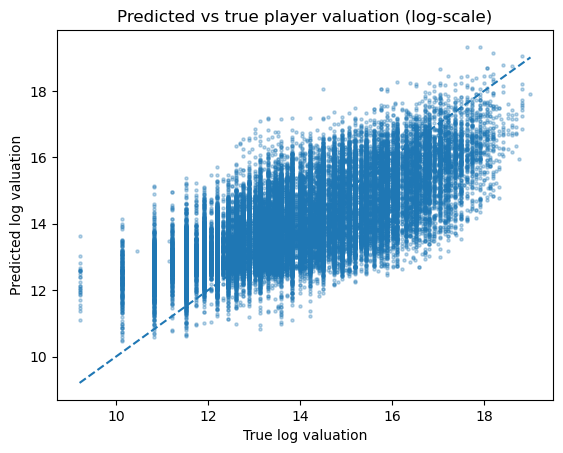

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(ytrue, yhat, s=5, alpha=0.3)
plt.plot([ytrue.min(), ytrue.max()],
         [ytrue.min(), ytrue.max()], linestyle="--")
plt.xlabel("True log valuation")
plt.ylabel("Predicted log valuation")
plt.title("Predicted vs true player valuation (log-scale)")
plt.show()

In [3]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

feature_cols = [
    c for c in numeric_df.columns
    if c not in ["y_log", "y_raw", "player_id"]
]

print("Antall features:", len(feature_cols))
for c in feature_cols:
    print(c)



Antall features: 15
height_in_cm
age_years
is_big5_league
mean_goals
mean_assists
mean_yellow_cards
mean_red_cards
mean_sub_in
mean_sub_out
sum_goals
sum_assists
sum_yellow_cards
sum_red_cards
sum_sub_in
sum_sub_out


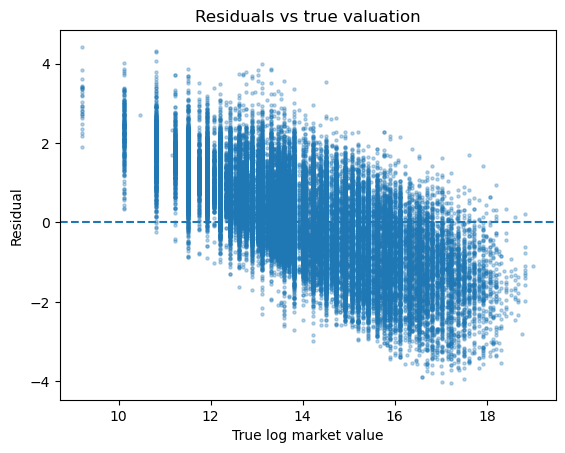

In [4]:
res = yhat - ytrue

plt.figure()
plt.scatter(ytrue, res, s=5, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("True log market value")
plt.ylabel("Residual")
plt.title("Residuals vs true valuation")
plt.show()
